In [7]:
# ============================================
# Standard library imports
# ============================================

import sys
import re
import logging
import warnings
from pathlib import Path

from IPython.display import display

warnings.filterwarnings("ignore")


# ============================================
# Numeric / statistics
# ============================================

import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr


# ============================================
# Machine learning / multivariate analysis
# ============================================

from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
)


# ============================================
# Plotting / visualization
# ============================================

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import seaborn as sns

# Optional: raincloud plot
try:
    import ptitprince as pt
    HAS_PTITPRINCE = True
except ImportError:
    HAS_PTITPRINCE = False
    print("ptitprince is not installed. RainCloud plots will be skipped.")


# ============================================
# Version info
# ============================================

print(f"python  = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas  = {pd.__version__}")
print(f"numpy   = {np.__version__}")
print(f"scipy   = {scipy.__version__}")

if HAS_PTITPRINCE:
    print("ptitprince imported successfully")


# ============================================
# Logging
# ============================================

logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python  = 3.11.15
pandas  = 2.3.3
numpy   = 2.4.6
scipy   = 1.17.1
ptitprince imported successfully


In [8]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=12,
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=11,
    legend_fontsize=12,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [9]:
# ============================================
# Feature annotation helpers
# ============================================

def feature_region(feature):

    if feature.startswith("5'UTR."):
        return "5'UTR"

    if feature.startswith("3'UTR."):
        return "3'UTR"

    if feature.startswith("CDS."):
        return "CDS"

    return "mRNA"


def feature_type(col):

    if col.endswith(".Length"):
        return "Length"

    if (
        ".uAUG" in col
        or ".uORF" in col
        or ".dAUG" in col
        or ".dORF" in col
    ):
        return "ORF_nonCDS"

    if col.endswith(".MFE"):
        return "RNA_structure_MFE"

    if ".wobble_pct_" in col:
        return "Wobble"

    if ".aa_pct_" in col:
        return "Amino_acid_composition"

    if ".dicodon_" in col:
        return "Dicodon"

    if re.search(r"\.[A-Z][a-z]{2}-[AUGC]{3}$", col):
        return "Codon_usage"

    if col.endswith("-freq"):
        return "Nucleotide_kmer_freq"

    return "Other"

In [10]:
# ============================================
# Load all feature importance tables
# ============================================

RESULT_DIR = Path("../results")

files = [
    ("AT21", "RF",   RESULT_DIR / "rf"   / "AT21.rf.feature_importance.tsv"),
    ("AT21", "LGBM", RESULT_DIR / "lgbm" / "AT21.lgbm.feature_importance.tsv"),

    ("NB21", "RF",   RESULT_DIR / "rf"   / "NB21.rf.feature_importance.tsv"),
    ("NB21", "LGBM", RESULT_DIR / "lgbm" / "NB21.lgbm.feature_importance.tsv"),

    ("OS21", "RF",   RESULT_DIR / "rf"   / "OS21.rf.feature_importance.tsv"),
    ("OS21", "LGBM", RESULT_DIR / "lgbm" / "OS21.lgbm.feature_importance.tsv"),
]

dfs = []

for species, model, path in files:

    df = pd.read_csv(path, sep="\t")

    df["species"] = species
    df["model"] = model

    dfs.append(df)

importance_all = pd.concat(
    dfs,
    ignore_index=True,
)

print(importance_all.shape)

display(
    importance_all.head()
)

# ============================================
# Feature importance matrix
# ============================================

importance_matrix = (
    importance_all
    .pivot_table(
        index="feature",
        columns=["species", "model"],
        values="importance",
        aggfunc="mean",
    )
)

importance_matrix.columns = [
    f"{sp}_{model}"
    for sp, model
    in importance_matrix.columns
]

importance_matrix = (
    importance_matrix
    .fillna(0)
)

print(
    importance_matrix.shape
)

display(
    importance_matrix.head()
)

# ============================================
# Yeo-Johnson + Z-score
# ============================================

importance_z = importance_matrix.copy()

for col in importance_z.columns:

    values = (
        importance_z[col]
        .values
        .reshape(-1, 1)
    )

    pt = PowerTransformer(
        method="yeo-johnson",
        standardize=False,
    )

    yj = pt.fit_transform(values).ravel()

    z = (
        yj - yj.mean()
    ) / yj.std(ddof=0)

    importance_z[col] = z

display(
    importance_z.head()
)

(2663, 5)


,species,model,rank,feature,importance
0,AT21,RF,1,CDS.G-freq,0.042472
1,AT21,RF,2,5'UTR.MFE,0.027173
2,AT21,RF,3,CDS.GG-freq,0.018439
3,AT21,RF,4,5'UTR.A-freq,0.016365
4,AT21,RF,5,CDS.AU-freq,0.015806


(458, 6)


,AT21_LGBM,AT21_RF,NB21_LGBM,NB21_RF,OS21_LGBM,OS21_RF
feature,,,,,,
3'UTR.A-freq,6.0,0.001423,5.0,0.001761,16.0,0.002054
3'UTR.AA-freq,14.0,0.002114,4.0,0.001256,16.0,0.001720
3'UTR.AAA-freq,3.0,0.002214,9.0,0.001568,10.0,0.002043
3'UTR.AAC-freq,14.0,0.002025,5.0,0.001599,10.0,0.002006
3'UTR.AAG-freq,11.0,0.002056,9.0,0.001902,6.0,0.002525


,AT21_LGBM,AT21_RF,NB21_LGBM,NB21_RF,OS21_LGBM,OS21_RF
feature,,,,,,
3'UTR.A-freq,-0.295270,-0.335975,0.048869,0.262981,1.027536,0.164903
3'UTR.AA-freq,1.071409,0.318318,-0.196245,-0.240525,1.027536,-0.131591
3'UTR.AAA-freq,-1.026447,0.401036,0.772070,0.077079,0.338470,0.155626
3'UTR.AAC-freq,1.071409,0.241849,0.048869,0.107541,0.338470,0.124375
3'UTR.AAG-freq,0.618852,0.269113,0.772070,0.393921,-0.274670,0.536958


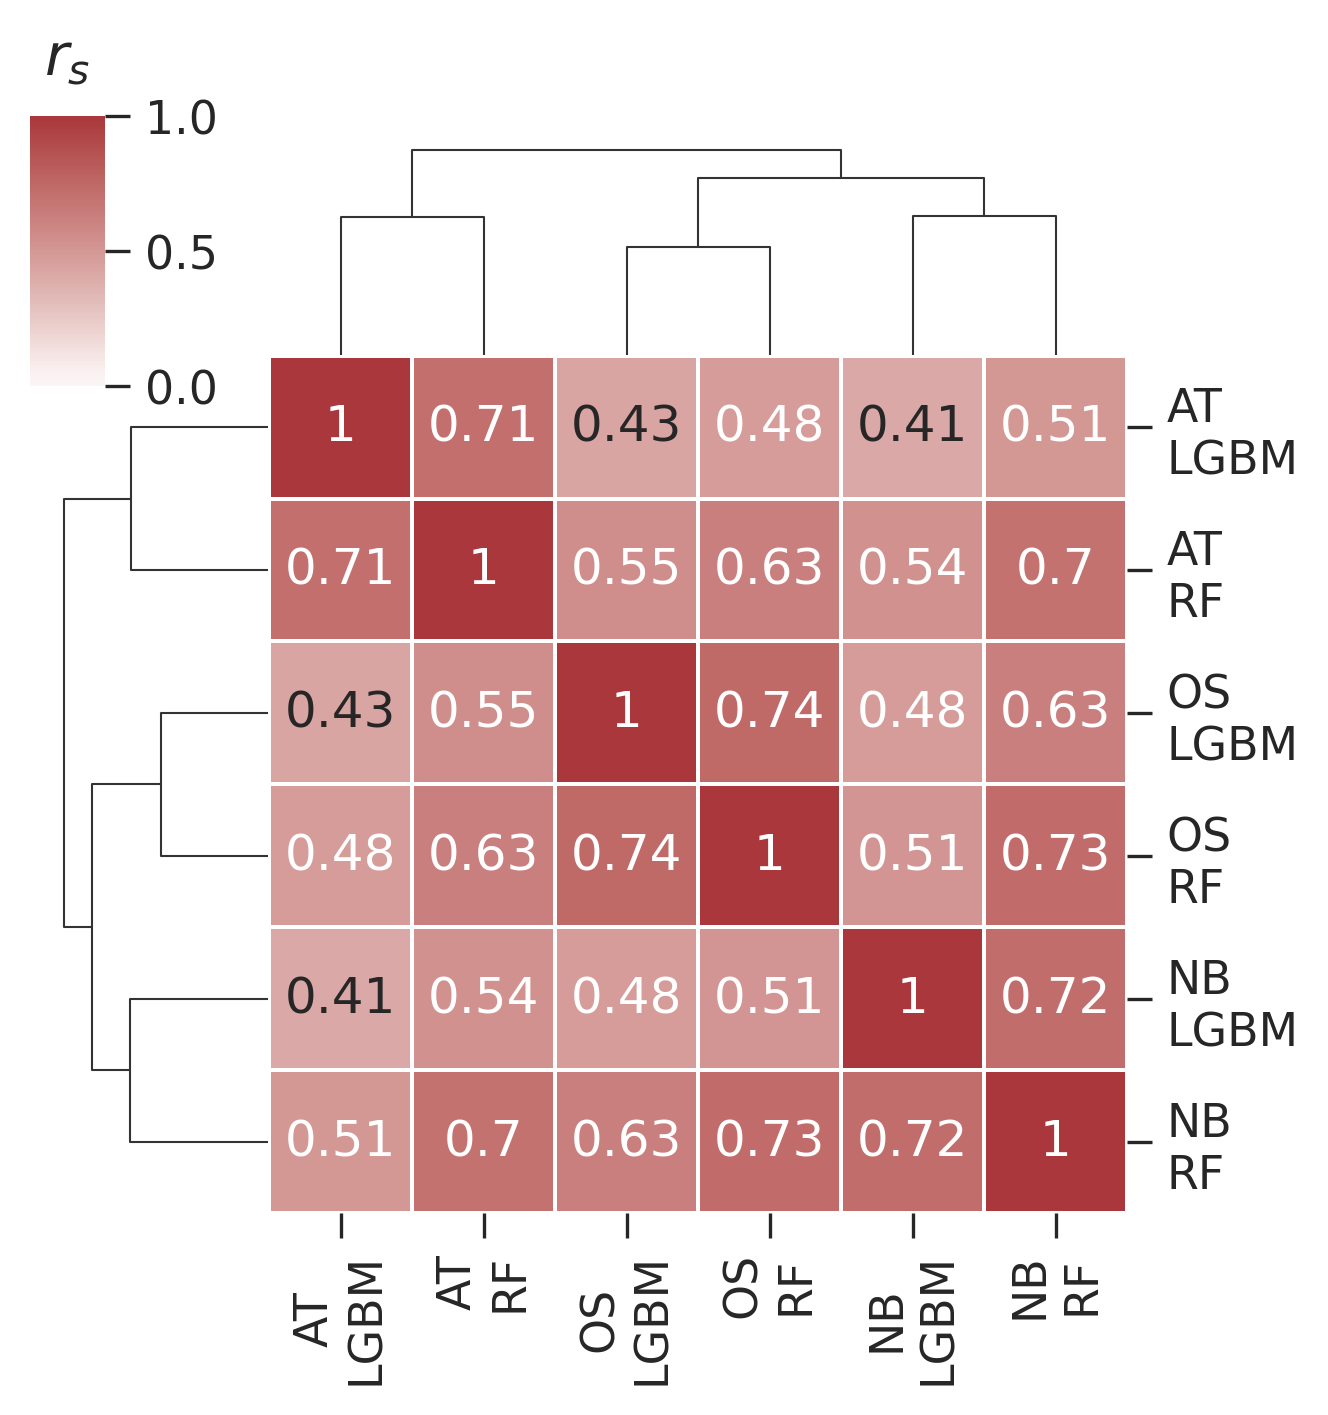

In [11]:
# ============================================
# Correlation heatmap
# ============================================

corr = importance_z.corr(
    method="spearman"
)

g = sns.clustermap(
    corr,
    cmap="vlag",
    center=0,
    vmin=0,
    vmax=1,
    annot=True,
    linewidths=0.5,
    figsize=(5, 5),
)

g.ax_heatmap.set_xticklabels(
    [
        x.get_text()
        .replace("AT21", "AT")
        .replace("NB21", "NB")
        .replace("OS21", "OS")
        .replace("_", "\n")
        for x in g.ax_heatmap.get_xticklabels()
    ]
)

g.ax_heatmap.set_yticklabels(
    [
        x.get_text()
        .replace("AT21", "AT")
        .replace("NB21", "NB")
        .replace("OS21", "OS")
        .replace("_", "\n")
        for x in g.ax_heatmap.get_yticklabels()
    ]
)

g.ax_cbar.set_title(
    r"$r_s$",
    pad=10,
)

plt.show()

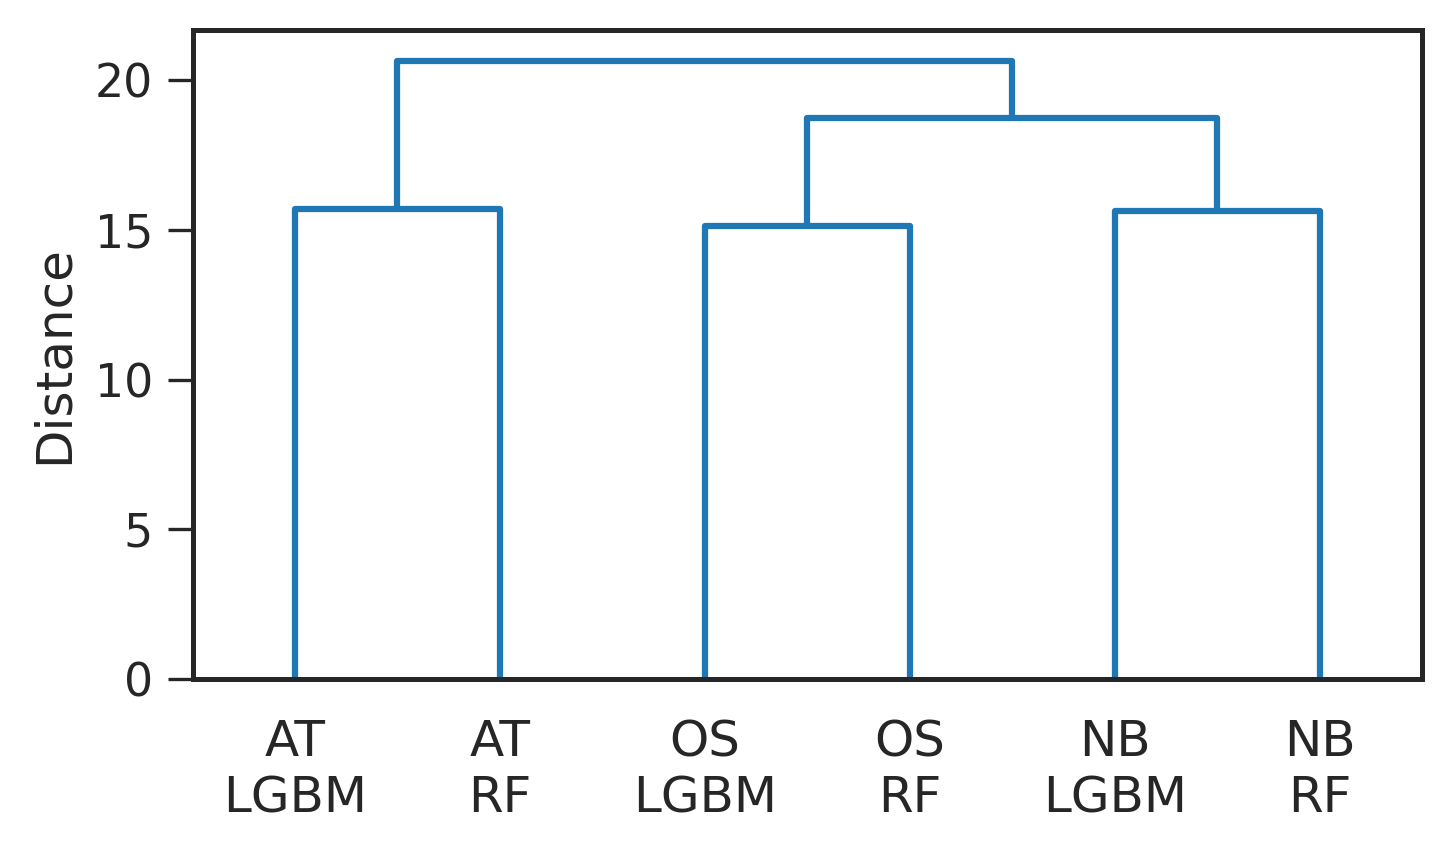

In [12]:
# ============================================
# Hierarchical clustering
# ============================================

linkage_matrix = linkage(
    importance_z.T,
    method="average",
    metric="euclidean",
)

fig, ax = make_fig(
    w=5,
    h=3,
)

dendrogram(
    linkage_matrix,
    labels=[
        x.replace("21_", "\n")
        for x in importance_z.columns
    ],
    ax=ax,
)

format_axis(
    ax,
    xlabel="",
    ylabel="Distance",
)

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# PCA
# ============================================

X = importance_z.T

pca = PCA(
    n_components=2
)

pcs = pca.fit_transform(X)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"],
    index=X.index,
)

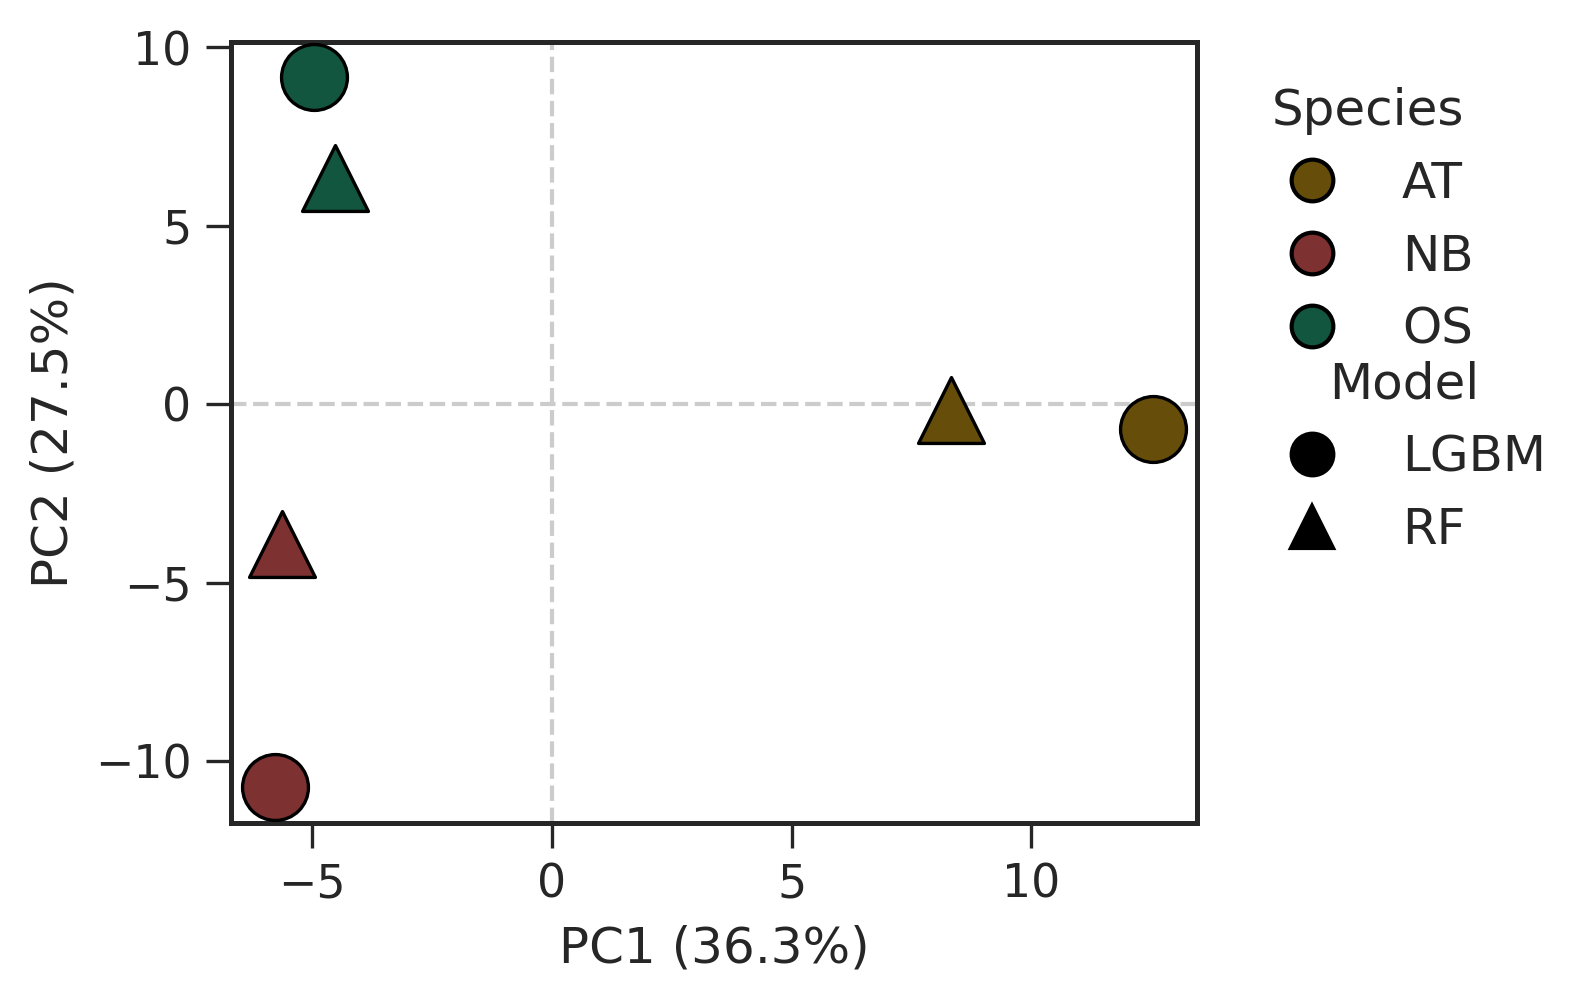

In [14]:
# ============================================
# PCA plot
# Color = species
# Shape = ML model
# ============================================

from matplotlib.lines import Line2D

MODEL_MARKERS = {
    "LGBM": "o",
    "RF": "^",
}

fig, ax = make_fig(
    w=5.5,
    h=3.5,
)

for sample in pca_df.index:

    species, model = sample.split("_")

    short_species = SPECIES_INFO[species]["label"]

    ax.scatter(
        pca_df.loc[sample, "PC1"],
        pca_df.loc[sample, "PC2"],
        s=250,
        color=SPECIES_INFO[species]["color"],
        marker=MODEL_MARKERS[model],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

ax.axhline(
    0,
    color="0.8",
    lw=1,
    ls="--",
)

ax.axvline(
    0,
    color="0.8",
    lw=1,
    ls="--",
)

ax.set_xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

# ----------------------------------
# Species legend (colors)
# ----------------------------------

species_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=SPECIES_INFO[sp]["color"],
        markeredgecolor="black",
        markersize=10,
        linestyle="None",
        label=SPECIES_INFO[sp]["label"],
    )
    for sp in ["AT21", "NB21", "OS21"]
]

legend_species = ax.legend(
    handles=species_handles,
    title="Species",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
)

ax.add_artist(legend_species)

# ----------------------------------
# Model legend (shapes)
# ----------------------------------

model_handles = [
    Line2D(
        [0], [0],
        marker=MODEL_MARKERS[m],
        color="black",
        markersize=10,
        linestyle="None",
        label=m,
    )
    for m in ["LGBM", "RF"]
]

ax.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.65),
)

plt.tight_layout()
plt.show()

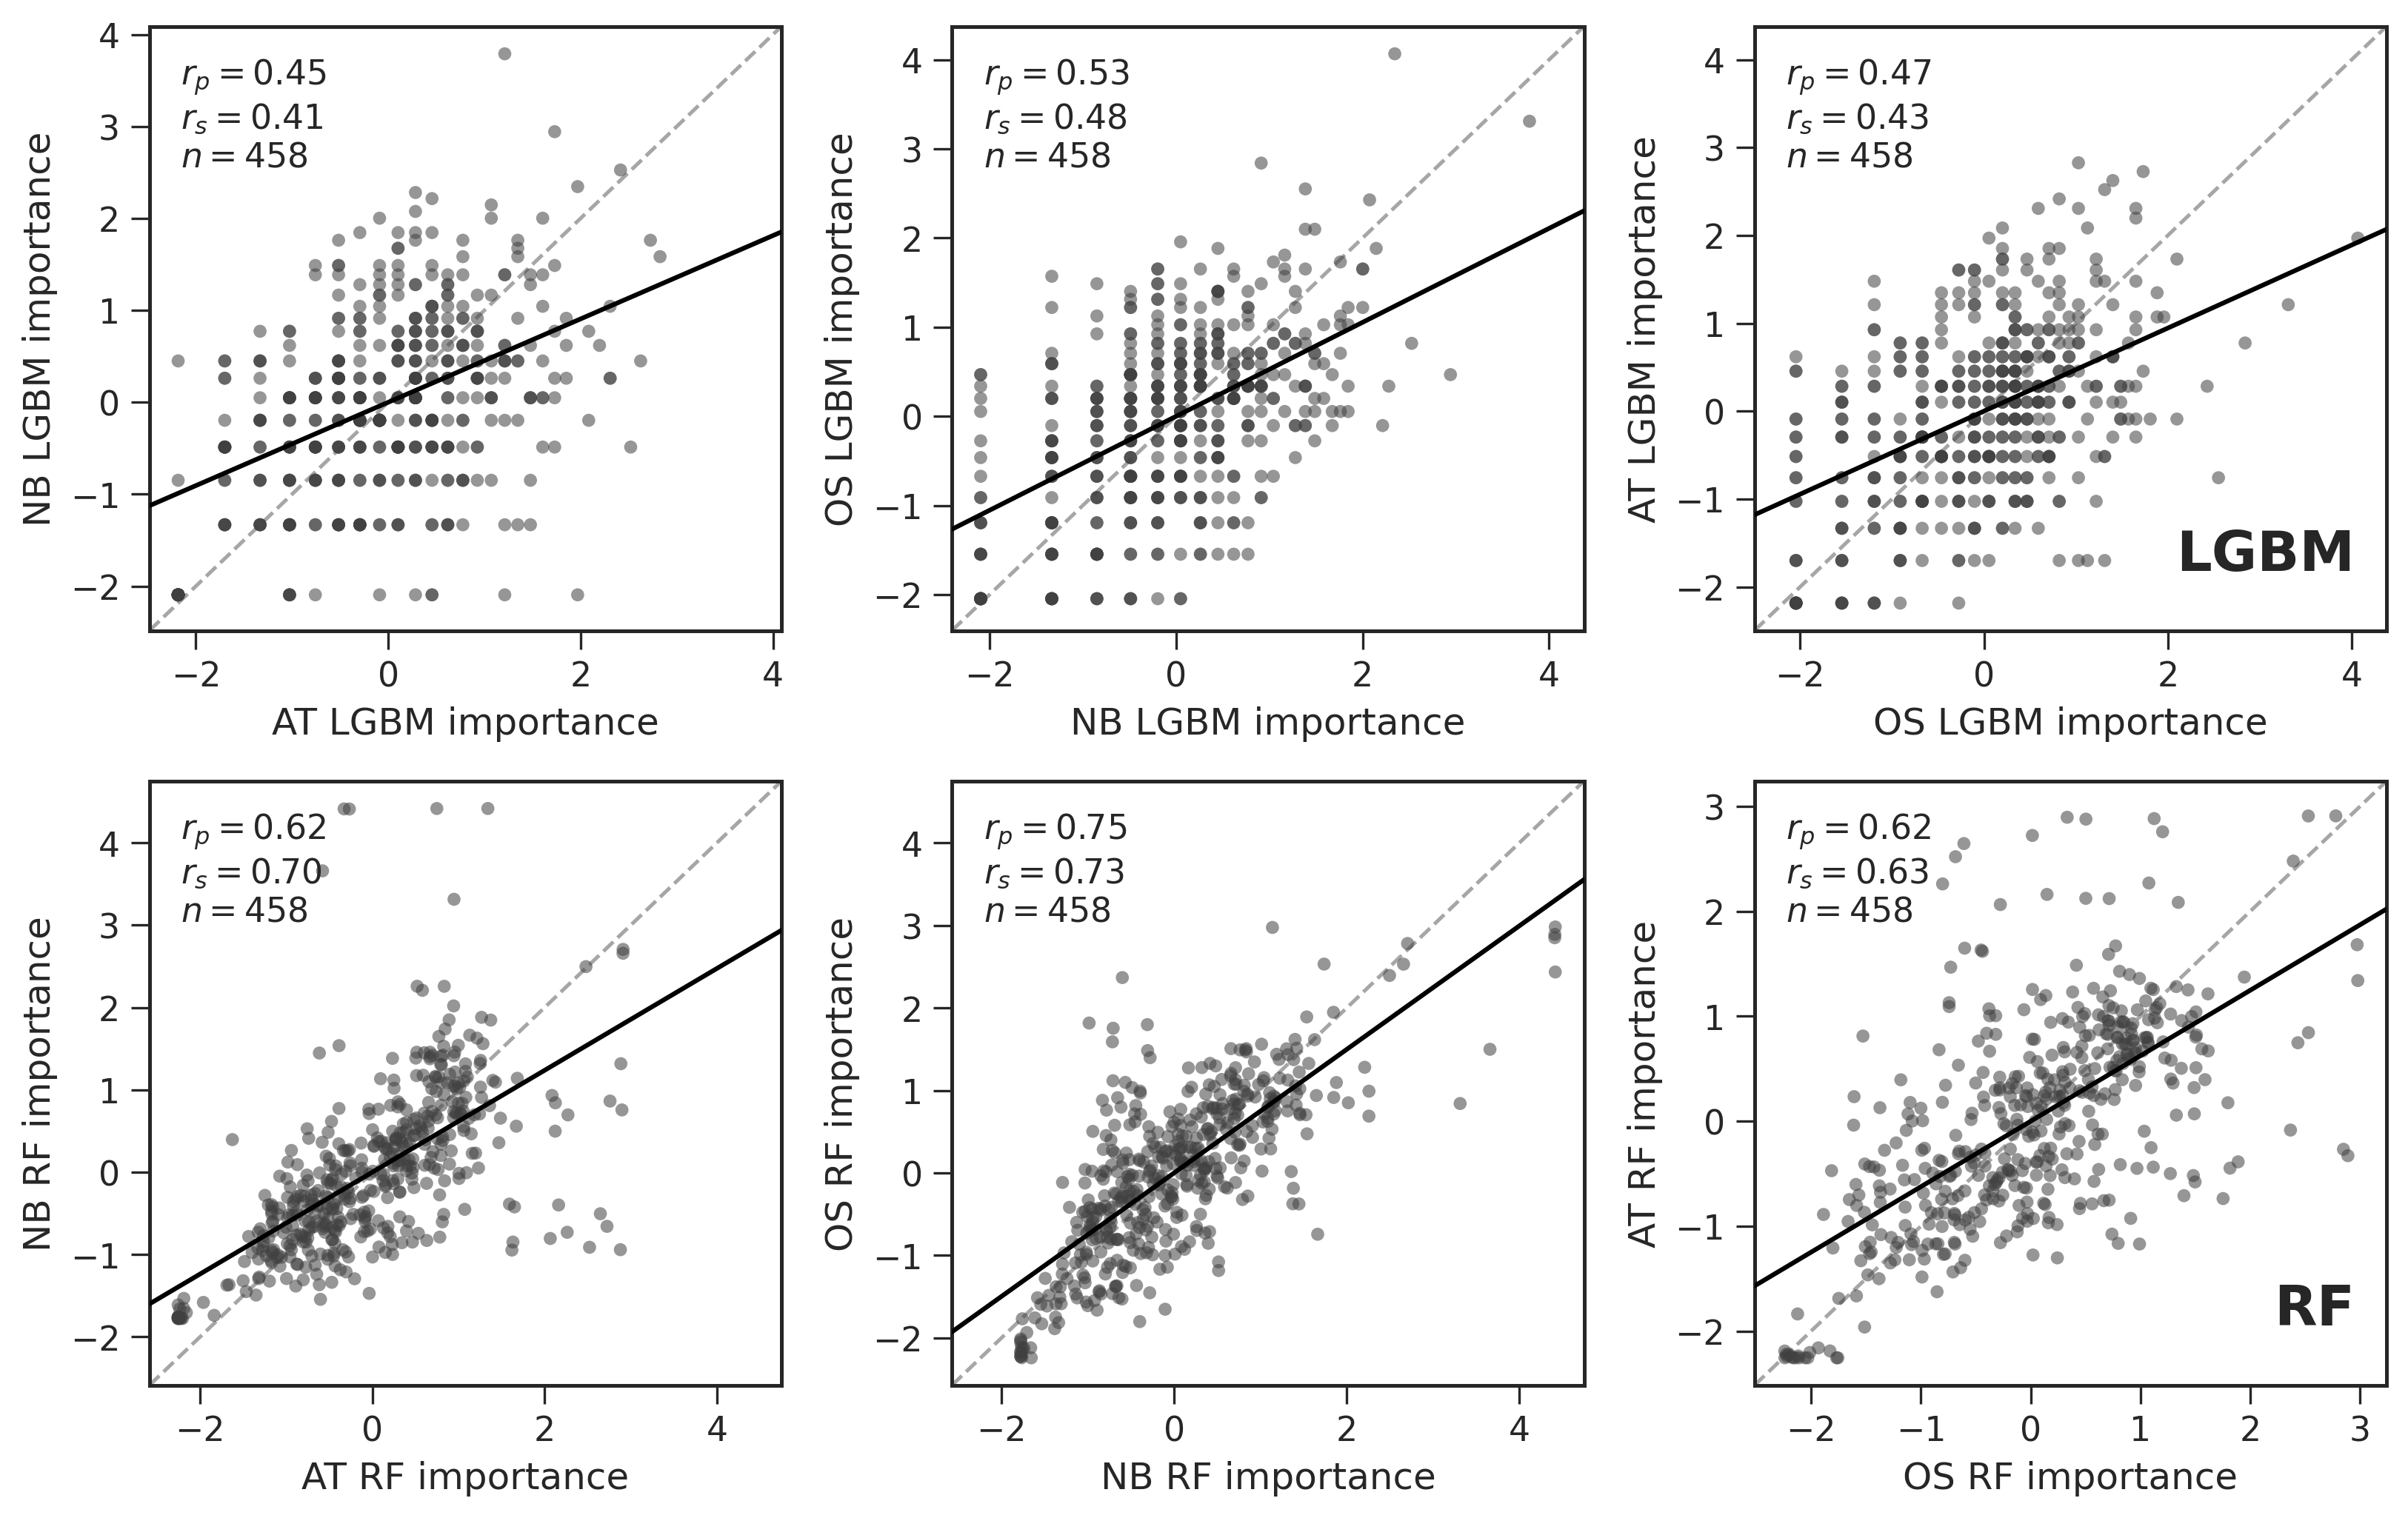

In [15]:
# ============================================
# Species-pair scatter plots before signed distance
# LGBM and RF
# ============================================

model_pairs = {
    "LGBM": [
        ("AT21_LGBM", "NB21_LGBM", "AT", "NB"),
        ("NB21_LGBM", "OS21_LGBM", "NB", "OS"),
        ("OS21_LGBM", "AT21_LGBM", "OS", "AT"),
    ],
    "RF": [
        ("AT21_RF", "NB21_RF", "AT", "NB"),
        ("NB21_RF", "OS21_RF", "NB", "OS"),
        ("OS21_RF", "AT21_RF", "OS", "AT"),
    ],
}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(11, 7),
    dpi=_PLOT_CFG["dpi"],
)

for row_idx, (model, pairs) in enumerate(model_pairs.items()):

    for col_idx, (xcol, ycol, xlabel, ylabel) in enumerate(pairs):

        ax = axes[row_idx, col_idx]

        plot_df = importance_z[
            [
                xcol,
                ycol,
            ]
        ].dropna()

        x = plot_df[xcol].to_numpy()
        y = plot_df[ycol].to_numpy()

        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        ax.scatter(
            x,
            y,
            s=18,
            alpha=0.55,
            color="0.25",
            edgecolor="none",
            zorder=2,
        )

        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        pad = 0.05 * (hi - lo)

        lo -= pad
        hi += pad

        ax.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

        if np.std(x) > 0 and np.std(y) > 0:

            slope, intercept = np.polyfit(
                x,
                y,
                1,
            )

            ax.plot(
                [lo, hi],
                slope * np.array([lo, hi]) + intercept,
                color="black",
                lw=1.5,
                zorder=3,
            )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        format_axis(
            ax,
            xlabel=f"{xlabel} {model} importance",
            ylabel=f"{ylabel} {model} importance",
        )

        ax.text(
            0.05,
            0.95,
            rf"$r_p = {rp:.2f}$"
            + "\n"
            + rf"$r_s = {rs:.2f}$"
            + "\n"
            + rf"$n = {len(x)}$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11,
        )

        if col_idx == 2:
            ax.text(
                0.95,
                0.08,
                model,
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=18,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# LGBM signed distance
# ============================================

AT = importance_z["AT21_LGBM"]
NB = importance_z["NB21_LGBM"]
OS = importance_z["OS21_LGBM"]

distance_lgbm = pd.DataFrame(
    index=importance_z.index
)

distance_lgbm["AT_specific"] = (
    np.sqrt(
        (AT - NB) ** 2
        +
        (AT - OS) ** 2
    )
    *
    np.sign(
        AT - (NB + OS) / 2
    )
)

distance_lgbm["NB_specific"] = (
    np.sqrt(
        (NB - AT) ** 2
        +
        (NB - OS) ** 2
    )
    *
    np.sign(
        NB - (AT + OS) / 2
    )
)

distance_lgbm["OS_specific"] = (
    np.sqrt(
        (OS - AT) ** 2
        +
        (OS - NB) ** 2
    )
    *
    np.sign(
        OS - (AT + NB) / 2
    )
)

distance_lgbm["Feature"] = (
    distance_lgbm.index
)

distance_lgbm["Feature_type"] = (
    distance_lgbm["Feature"]
    .apply(feature_type)
)

distance_lgbm["Region"] = (
    distance_lgbm["Feature"]
    .apply(feature_region)
)

distance_long_lgbm = (
    distance_lgbm
    .reset_index(drop=True)
    .melt(
        id_vars=[
            "Feature",
            "Feature_type",
            "Region",
        ],
        value_vars=[
            "AT_specific",
            "NB_specific",
            "OS_specific",
        ],
        var_name="Species",
        value_name="Signed_distance",
    )
)

distance_long_lgbm["Species"] = (
    distance_long_lgbm["Species"]
    .str.replace(
        "_specific",
        "",
        regex=False,
    )
)

distance_long_lgbm["Abs_distance"] = (
    distance_long_lgbm["Signed_distance"]
    .abs()
)

display(
    distance_long_lgbm.head()
)

# ============================================
# RF signed distance
# ============================================

AT = importance_z["AT21_RF"]
NB = importance_z["NB21_RF"]
OS = importance_z["OS21_RF"]

distance_rf = pd.DataFrame(
    index=importance_z.index
)

distance_rf["AT_specific"] = (
    np.sqrt(
        (AT - NB) ** 2
        +
        (AT - OS) ** 2
    )
    *
    np.sign(
        AT - (NB + OS) / 2
    )
)

distance_rf["NB_specific"] = (
    np.sqrt(
        (NB - AT) ** 2
        +
        (NB - OS) ** 2
    )
    *
    np.sign(
        NB - (AT + OS) / 2
    )
)

distance_rf["OS_specific"] = (
    np.sqrt(
        (OS - AT) ** 2
        +
        (OS - NB) ** 2
    )
    *
    np.sign(
        OS - (AT + NB) / 2
    )
)

distance_rf["Feature"] = (
    distance_rf.index
)

distance_rf["Feature_type"] = (
    distance_rf["Feature"]
    .apply(feature_type)
)

distance_rf["Region"] = (
    distance_rf["Feature"]
    .apply(feature_region)
)

distance_long_rf = (
    distance_rf
    .reset_index(drop=True)
    .melt(
        id_vars=[
            "Feature",
            "Feature_type",
            "Region",
        ],
        value_vars=[
            "AT_specific",
            "NB_specific",
            "OS_specific",
        ],
        var_name="Species",
        value_name="Signed_distance",
    )
)

distance_long_rf["Species"] = (
    distance_long_rf["Species"]
    .str.replace(
        "_specific",
        "",
        regex=False,
    )
)

distance_long_rf["Abs_distance"] = (
    distance_long_rf["Signed_distance"]
    .abs()
)

display(
    distance_long_rf.head()
)

,Feature,Feature_type,Region,Species,Signed_distance,Abs_distance
0,3'UTR.A-freq,Nucleotide_kmer_freq,3'UTR,AT,-1.366838,1.366838
1,3'UTR.AA-freq,Nucleotide_kmer_freq,3'UTR,AT,1.268413,1.268413
2,3'UTR.AAA-freq,Nucleotide_kmer_freq,3'UTR,AT,-2.257801,2.257801
3,3'UTR.AAC-freq,Nucleotide_kmer_freq,3'UTR,AT,1.258089,1.258089
4,3'UTR.AAG-freq,Nucleotide_kmer_freq,3'UTR,AT,0.906563,0.906563


,Feature,Feature_type,Region,Species,Signed_distance,Abs_distance
0,3'UTR.A-freq,Nucleotide_kmer_freq,3'UTR,AT,-0.780786,0.780786
1,3'UTR.AA-freq,Nucleotide_kmer_freq,3'UTR,AT,0.717443,0.717443
2,3'UTR.AAA-freq,Nucleotide_kmer_freq,3'UTR,AT,0.406417,0.406417
3,3'UTR.AAC-freq,Nucleotide_kmer_freq,3'UTR,AT,0.178435,0.178435
4,3'UTR.AAG-freq,Nucleotide_kmer_freq,3'UTR,AT,-0.295496,0.295496


In [17]:
# ============================================
# Keep informative feature classes
# LGBM and RF separately
# ============================================

keep_feature_types = [
    "Nucleotide_kmer_freq",
    "Length",
    "RNA_structure_MFE",
    "Codon_usage",
    "Amino_acid_composition",
    "Wobble",
]

distance_long_lgbm_keep = (
    distance_long_lgbm[
        distance_long_lgbm["Feature_type"]
        .isin(keep_feature_types)
    ]
    .copy()
)

distance_long_rf_keep = (
    distance_long_rf[
        distance_long_rf["Feature_type"]
        .isin(keep_feature_types)
    ]
    .copy()
)

display(
    distance_long_lgbm_keep.head()
)

display(
    distance_long_rf_keep.head()
)

,Feature,Feature_type,Region,Species,Signed_distance,Abs_distance
0,3'UTR.A-freq,Nucleotide_kmer_freq,3'UTR,AT,-1.366838,1.366838
1,3'UTR.AA-freq,Nucleotide_kmer_freq,3'UTR,AT,1.268413,1.268413
2,3'UTR.AAA-freq,Nucleotide_kmer_freq,3'UTR,AT,-2.257801,2.257801
3,3'UTR.AAC-freq,Nucleotide_kmer_freq,3'UTR,AT,1.258089,1.258089
4,3'UTR.AAG-freq,Nucleotide_kmer_freq,3'UTR,AT,0.906563,0.906563


,Feature,Feature_type,Region,Species,Signed_distance,Abs_distance
0,3'UTR.A-freq,Nucleotide_kmer_freq,3'UTR,AT,-0.780786,0.780786
1,3'UTR.AA-freq,Nucleotide_kmer_freq,3'UTR,AT,0.717443,0.717443
2,3'UTR.AAA-freq,Nucleotide_kmer_freq,3'UTR,AT,0.406417,0.406417
3,3'UTR.AAC-freq,Nucleotide_kmer_freq,3'UTR,AT,0.178435,0.178435
4,3'UTR.AAG-freq,Nucleotide_kmer_freq,3'UTR,AT,-0.295496,0.295496


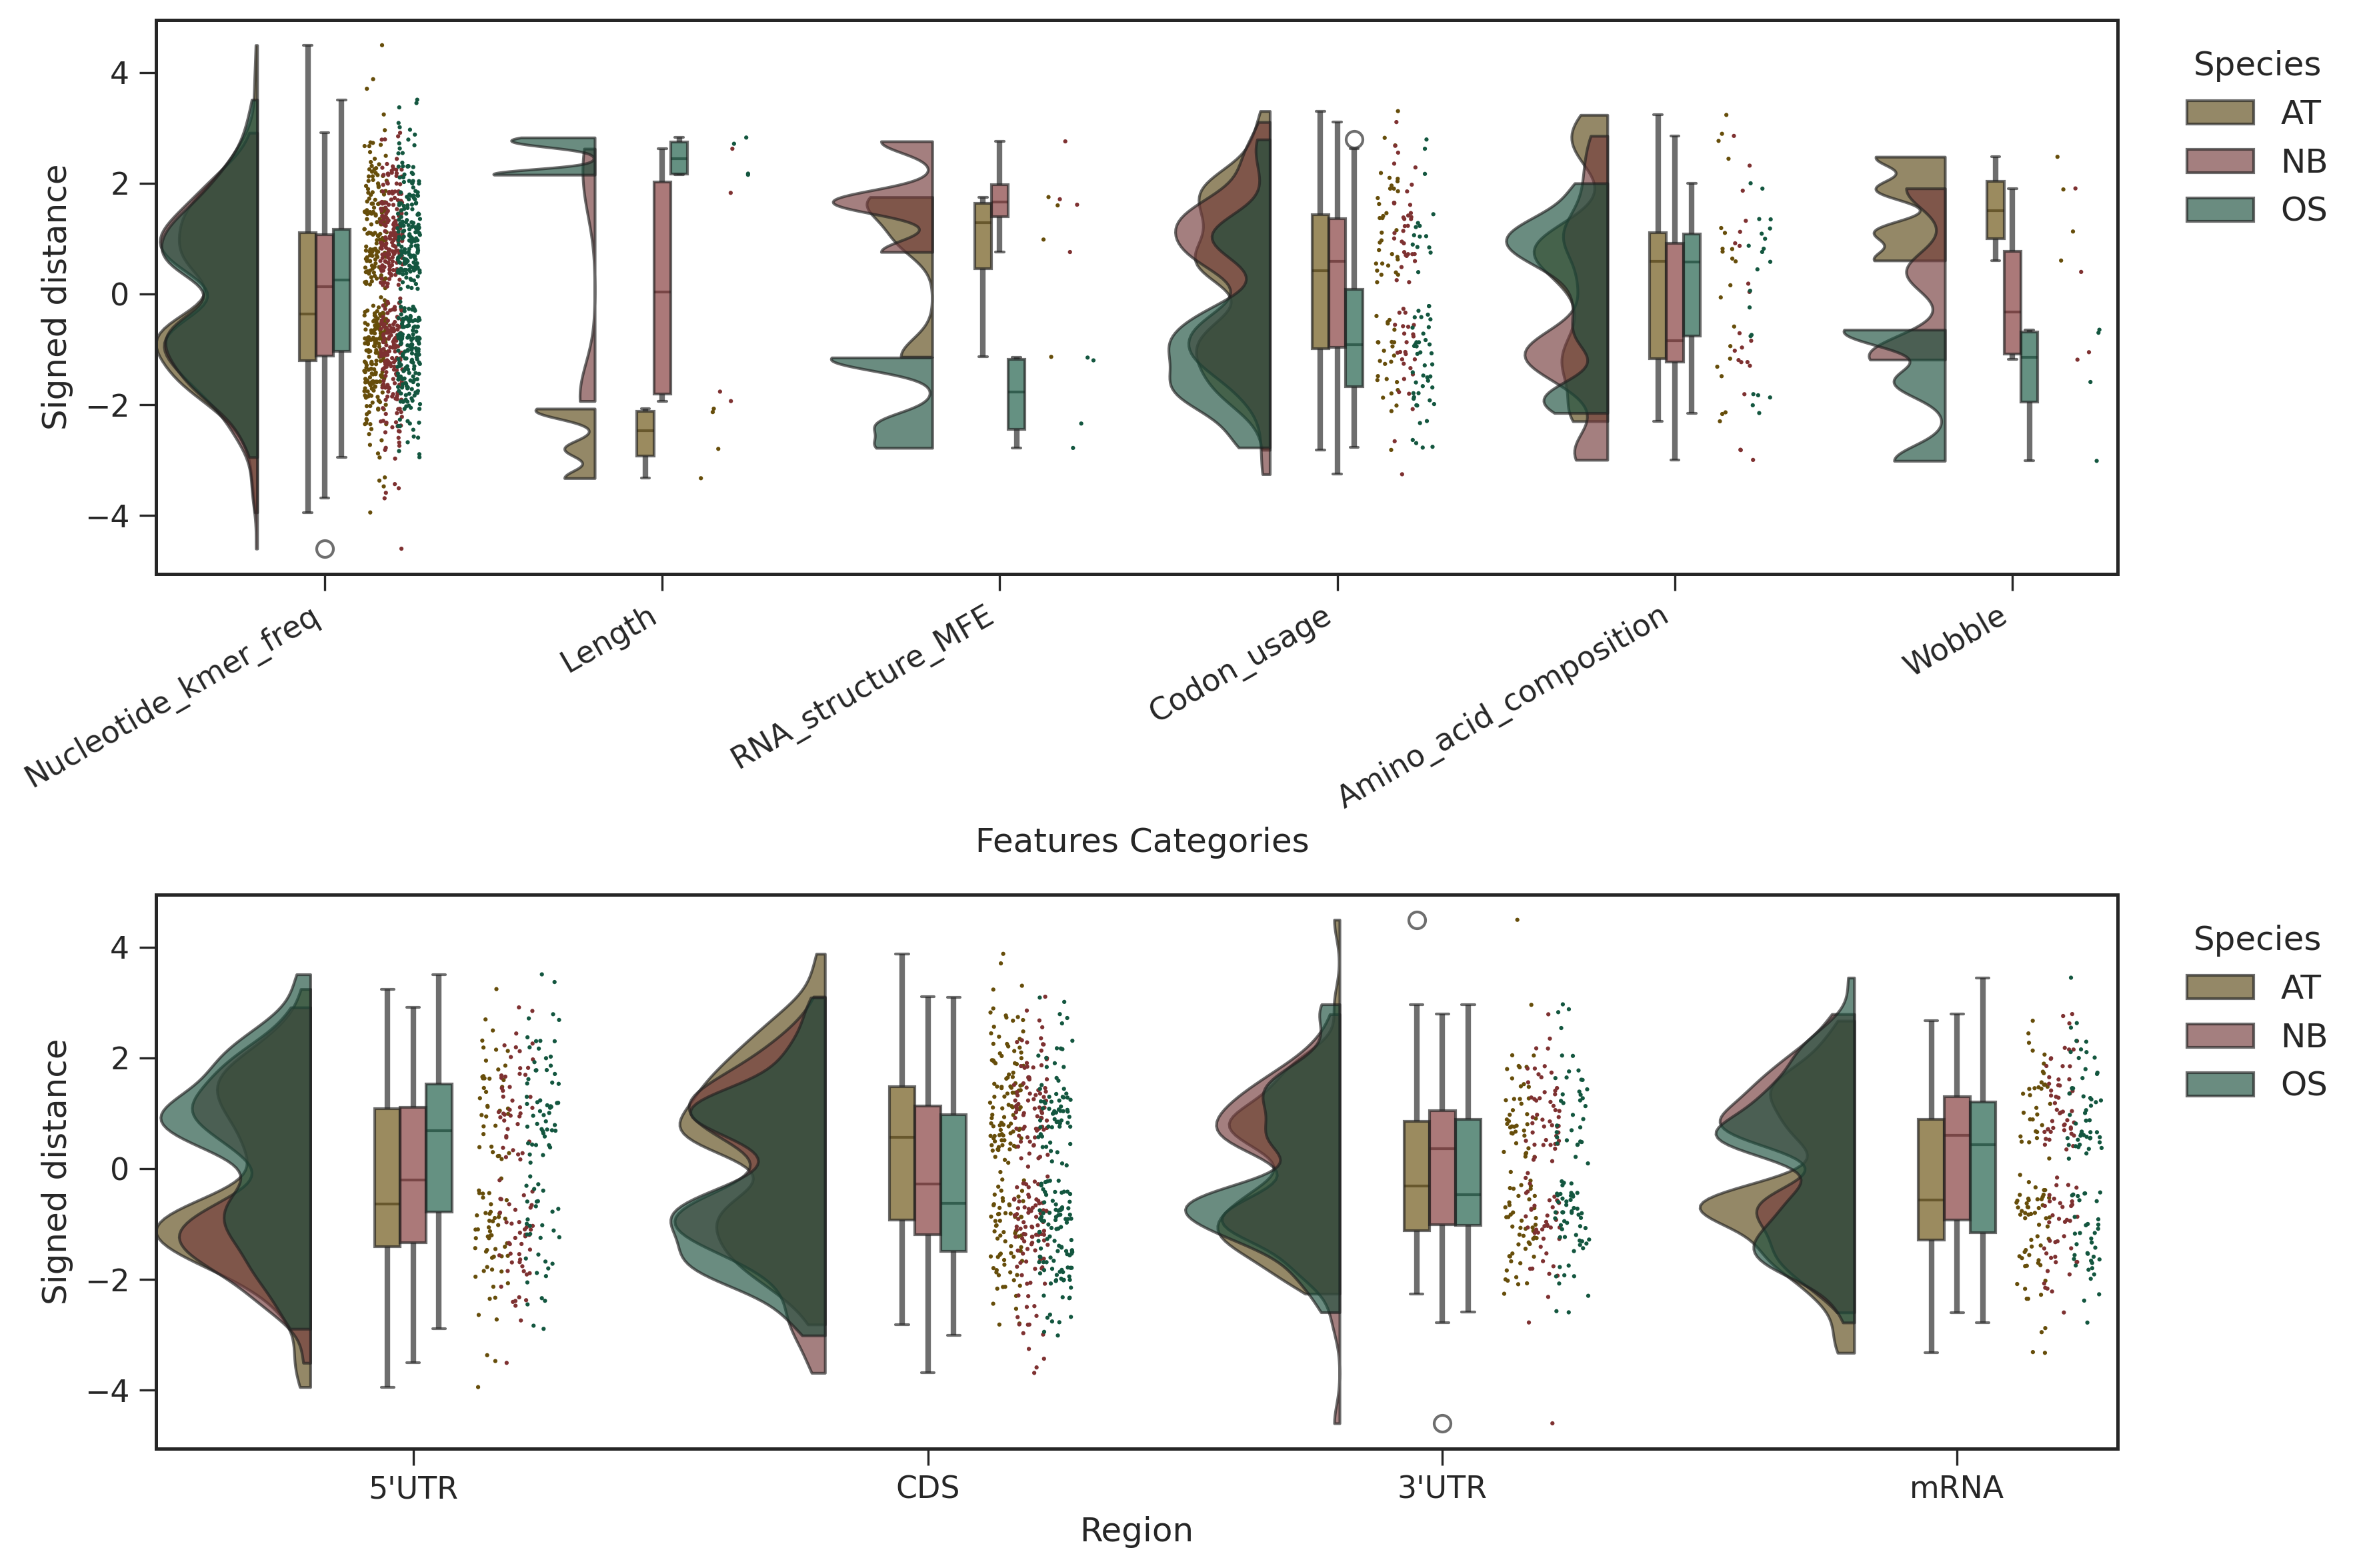

In [18]:
# ============================================
# LGBM RainCloud
# Feature type + Region
# ============================================

import ptitprince as pt

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    dpi=_PLOT_CFG["dpi"],
)

# --------------------------------------------
# Feature type
# --------------------------------------------

ax = axes[0]

pt.RainCloud(
    data=distance_long_lgbm_keep,
    x="Feature_type",
    y="Signed_distance",
    hue="Species",
    order=keep_feature_types,
    palette=species_palette(),
    bw=0.25,
    width_viol=0.6,
    width_box=0.15,
    orient="v",
    move=0.2,
    alpha=0.65,
    dodge=True,
    point_size=1.5,
    ax=ax,
)

format_axis(
    ax,
    xlabel=" Features Categories",
    ylabel="Signed distance",
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:3],
    labels[:3],
    title="Species",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

# --------------------------------------------
# Region
# --------------------------------------------

ax = axes[1]

region_order = [
    "5'UTR",
    "CDS",
    "3'UTR",
    "mRNA",
]

pt.RainCloud(
    data=distance_long_lgbm_keep,
    x="Region",
    y="Signed_distance",
    hue="Species",
    order=region_order,
    palette=species_palette(),
    bw=0.25,
    width_viol=0.6,
    width_box=0.15,
    orient="v",
    move=0.2,
    alpha=0.65,
    dodge=True,
    point_size=1.5,
    ax=ax,
)

format_axis(
    ax,
    xlabel="Region",
    ylabel="Signed distance",
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:3],
    labels[:3],
    title="Species",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
)

plt.tight_layout()
plt.show()

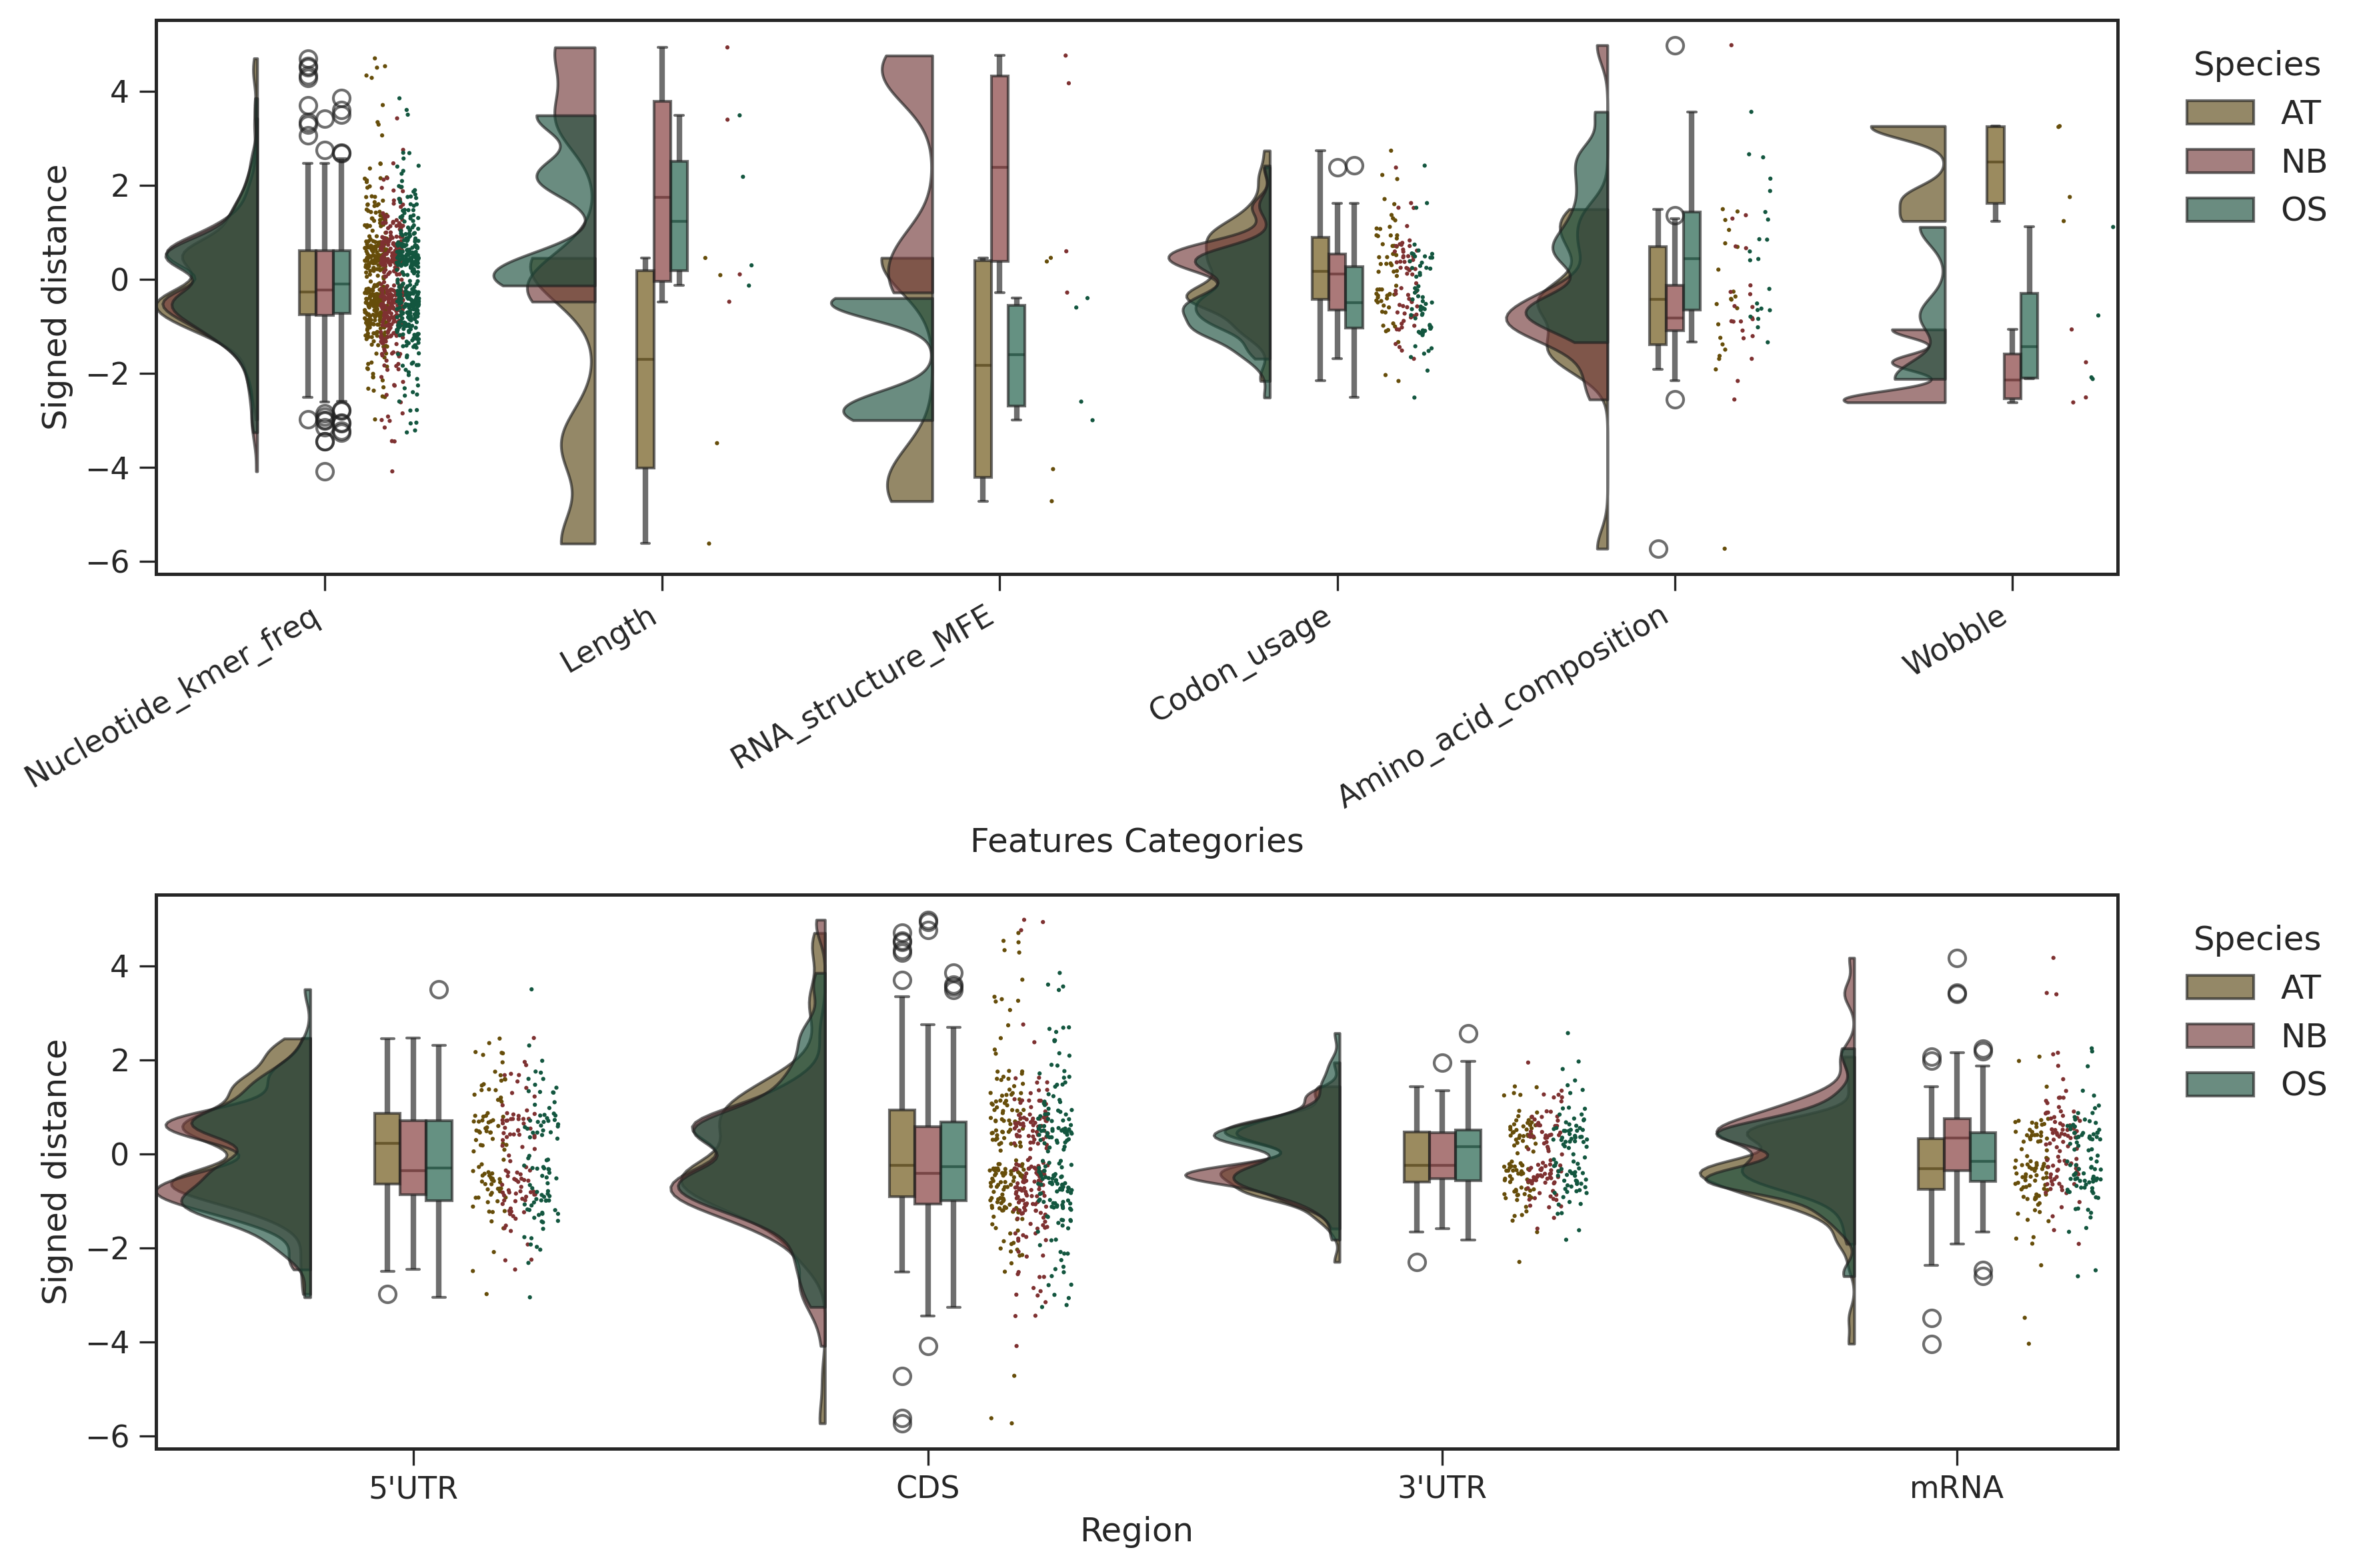

In [19]:
# ============================================
# RF RainCloud
# Feature type + Region
# ============================================

import ptitprince as pt

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    dpi=_PLOT_CFG["dpi"],
)

# --------------------------------------------
# Feature type
# --------------------------------------------

ax = axes[0]

pt.RainCloud(
    data=distance_long_rf_keep,
    x="Feature_type",
    y="Signed_distance",
    hue="Species",
    order=keep_feature_types,
    palette=species_palette(),
    bw=0.25,
    width_viol=0.6,
    width_box=0.15,
    orient="v",
    move=0.2,
    alpha=0.65,
    dodge=True,
    point_size=1.5,
    ax=ax,
)

format_axis(
    ax,
    xlabel="Features Categories",
    ylabel="Signed distance",
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:3],
    labels[:3],
    title="Species",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

# --------------------------------------------
# Region
# --------------------------------------------

ax = axes[1]

region_order = [
    "5'UTR",
    "CDS",
    "3'UTR",
    "mRNA",
]

pt.RainCloud(
    data=distance_long_rf_keep,
    x="Region",
    y="Signed_distance",
    hue="Species",
    order=region_order,
    palette=species_palette(),
    bw=0.25,
    width_viol=0.6,
    width_box=0.15,
    orient="v",
    move=0.2,
    alpha=0.65,
    dodge=True,
    point_size=1.5,
    ax=ax,
)

format_axis(
    ax,
    xlabel="Region",
    ylabel="Signed distance",
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:3],
    labels[:3],
    title="Species",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
)

plt.tight_layout()
plt.show()

In [20]:
# ============================================
# LGBM candidate table
# Best positive signed-distance feature
# per feature class × species
# ============================================

candidate_rows = []

for ft in keep_feature_types:

    tmp = distance_long_lgbm[
        distance_long_lgbm["Feature_type"] == ft
    ].copy()

    if tmp.empty:
        continue

    for sp in ["AT", "NB", "OS"]:

        tmp_sp = tmp[
            tmp["Species"] == sp
        ].copy()

        best_idx = tmp_sp["Signed_distance"].idxmax()

        candidate_rows.append({
            "Feature_class": ft,
            "Species": sp,
            "Candidate": tmp_sp.loc[best_idx, "Feature"],
            "Signed_distance": tmp_sp.loc[best_idx, "Signed_distance"],
            "Abs_distance": tmp_sp.loc[best_idx, "Abs_distance"],
        })

candidate_table_lgbm = pd.DataFrame(candidate_rows)

display(candidate_table_lgbm)

,Feature_class,Species,Candidate,Signed_distance,Abs_distance
0,Nucleotide_kmer_freq,AT,3'UTR.UAG-freq,4.492638,4.492638
1,Nucleotide_kmer_freq,NB,5'UTR.UG-freq,2.911068,2.911068
2,Nucleotide_kmer_freq,OS,5'UTR.UC-freq,3.507940,3.507940
3,Length,AT,3'UTR.Length,-2.069673,2.069673
4,Length,NB,mRNA.Length,2.623011,2.623011
5,Length,OS,3'UTR.Length,2.824945,2.824945
6,RNA_structure_MFE,AT,mRNA.MFE,1.750413,1.750413
7,RNA_structure_MFE,NB,mRNA.MFE,2.756040,2.756040
8,RNA_structure_MFE,OS,CDS.MFE,-1.147306,1.147306
9,Codon_usage,AT,CDS.Gln-CAA,3.302443,3.302443


In [21]:
# ============================================
# RF candidate table
# Best positive signed-distance feature
# per feature class × species
# ============================================

candidate_rows = []

for ft in keep_feature_types:

    tmp = distance_long_rf[
        distance_long_rf["Feature_type"] == ft
    ].copy()

    if tmp.empty:
        continue

    for sp in ["AT", "NB", "OS"]:

        tmp_sp = tmp[
            tmp["Species"] == sp
        ].copy()

        best_idx = tmp_sp["Signed_distance"].idxmax()

        candidate_rows.append({
            "Feature_class": ft,
            "Species": sp,
            "Candidate": tmp_sp.loc[best_idx, "Feature"],
            "Signed_distance": tmp_sp.loc[best_idx, "Signed_distance"],
            "Abs_distance": tmp_sp.loc[best_idx, "Abs_distance"],
        })

candidate_table_rf = pd.DataFrame(candidate_rows)

display(candidate_table_rf)

,Feature_class,Species,Candidate,Signed_distance,Abs_distance
0,Nucleotide_kmer_freq,AT,CDS.UAU-freq,4.697831,4.697831
1,Nucleotide_kmer_freq,NB,mRNA.C-freq,3.422014,3.422014
2,Nucleotide_kmer_freq,OS,CDS.UC-freq,3.848660,3.848660
3,Length,AT,3'UTR.Length,0.453302,0.453302
4,Length,NB,CDS.Length,4.930627,4.930627
5,Length,OS,CDS.Length,3.485909,3.485909
6,RNA_structure_MFE,AT,5'UTR.MFE,0.455414,0.455414
7,RNA_structure_MFE,NB,CDS.MFE,4.757027,4.757027
8,RNA_structure_MFE,OS,5'UTR.MFE,-0.400763,0.400763
9,Codon_usage,AT,CDS.Lys-AAG,2.734954,2.734954


In [22]:
# ============================================
# Candidate comparison
# ============================================

candidate_compare = (
    candidate_table_lgbm
    .merge(
        candidate_table_rf,
        on=["Feature_class", "Species"],
        suffixes=("_LGBM", "_RF"),
    )
)

display(candidate_compare)

,Feature_class,Species,Candidate_LGBM,Signed_distance_LGBM,Abs_distance_LGBM,Candidate_RF,Signed_distance_RF,Abs_distance_RF
0,Nucleotide_kmer_freq,AT,3'UTR.UAG-freq,4.492638,4.492638,CDS.UAU-freq,4.697831,4.697831
1,Nucleotide_kmer_freq,NB,5'UTR.UG-freq,2.911068,2.911068,mRNA.C-freq,3.422014,3.422014
2,Nucleotide_kmer_freq,OS,5'UTR.UC-freq,3.507940,3.507940,CDS.UC-freq,3.848660,3.848660
3,Length,AT,3'UTR.Length,-2.069673,2.069673,3'UTR.Length,0.453302,0.453302
4,Length,NB,mRNA.Length,2.623011,2.623011,CDS.Length,4.930627,4.930627
5,Length,OS,3'UTR.Length,2.824945,2.824945,CDS.Length,3.485909,3.485909
6,RNA_structure_MFE,AT,mRNA.MFE,1.750413,1.750413,5'UTR.MFE,0.455414,0.455414
7,RNA_structure_MFE,NB,mRNA.MFE,2.756040,2.756040,CDS.MFE,4.757027,4.757027
8,RNA_structure_MFE,OS,CDS.MFE,-1.147306,1.147306,5'UTR.MFE,-0.400763,0.400763
9,Codon_usage,AT,CDS.Gln-CAA,3.302443,3.302443,CDS.Lys-AAG,2.734954,2.734954


In [23]:
# ============================================
# LGBM candidate pools
# top 5% signed distance
# ============================================

quantile_cutoff = 0.95

candidate_pools_lgbm = []

for ft in keep_feature_types:

    tmp = distance_long_lgbm_keep[
        distance_long_lgbm_keep["Feature_type"] == ft
    ].copy()

    for sp in ["AT", "NB", "OS"]:

        tmp_sp = tmp[
            tmp["Species"] == sp
        ].copy()

        cutoff = (
            tmp_sp["Signed_distance"]
            .quantile(quantile_cutoff)
        )

        selected = tmp_sp[
            tmp_sp["Signed_distance"] >= cutoff
        ].copy()

        selected["Cutoff"] = cutoff

        candidate_pools_lgbm.append(
            selected
        )

candidate_pool_lgbm = pd.concat(
    candidate_pools_lgbm,
    ignore_index=True,
)

display(
    candidate_pool_lgbm.head()
)

print(
    candidate_pool_lgbm.shape
)

,Feature,Feature_type,Region,Species,Signed_distance,Abs_distance,Cutoff
0,3'UTR.GAU-freq,Nucleotide_kmer_freq,3'UTR,AT,2.957924,2.957924,2.252777
1,3'UTR.UAG-freq,Nucleotide_kmer_freq,3'UTR,AT,4.492638,4.492638,2.252777
2,5'UTR.S-freq,Nucleotide_kmer_freq,5'UTR,AT,2.495389,2.495389,2.252777
3,5'UTR.U-freq,Nucleotide_kmer_freq,5'UTR,AT,3.241735,3.241735,2.252777
4,5'UTR.UA-freq,Nucleotide_kmer_freq,5'UTR,AT,2.693891,2.693891,2.252777


(78, 7)


In [24]:
# ============================================
# RF candidate pools
# top 5% signed distance
# ============================================

quantile_cutoff = 0.95

candidate_pools_rf = []

for ft in keep_feature_types:

    tmp = distance_long_rf_keep[
        distance_long_rf_keep["Feature_type"] == ft
    ].copy()

    for sp in ["AT", "NB", "OS"]:

        tmp_sp = tmp[
            tmp["Species"] == sp
        ].copy()

        cutoff = (
            tmp_sp["Signed_distance"]
            .quantile(quantile_cutoff)
        )

        selected = tmp_sp[
            tmp_sp["Signed_distance"] >= cutoff
        ].copy()

        selected["Cutoff"] = cutoff

        candidate_pools_rf.append(
            selected
        )

candidate_pool_rf = pd.concat(
    candidate_pools_rf,
    ignore_index=True,
)

display(
    candidate_pool_rf.head()
)

print(
    candidate_pool_rf.shape
)

,Feature,Feature_type,Region,Species,Signed_distance,Abs_distance,Cutoff
0,5'UTR.A-freq,Nucleotide_kmer_freq,5'UTR,AT,2.356641,2.356641,1.970517
1,5'UTR.AAA-freq,Nucleotide_kmer_freq,5'UTR,AT,2.139768,2.139768,1.970517
2,5'UTR.AGA-freq,Nucleotide_kmer_freq,5'UTR,AT,2.105193,2.105193,1.970517
3,5'UTR.GG-freq,Nucleotide_kmer_freq,5'UTR,AT,2.166115,2.166115,1.970517
4,5'UTR.K-freq,Nucleotide_kmer_freq,5'UTR,AT,2.149214,2.149214,1.970517


(78, 7)
